<a href="https://colab.research.google.com/github/aishwarya-patil-bit/Java-Calculator/blob/main/MlPractical2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.  Student Name: Aishwarya Laxman Patil
2.  Div: A
3.  Batch: A1
4.  Roll No.: 11
5.  Date: 00/09/2026
6.  Practical No.: 02
7.  Practical Name:Train logistic regression for binary classification. Visualize the sigmoid function and decision boundary. Analyze ROC curve and AUC.

Logistic Regression


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
# Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


1. Data loading

In [5]:
#Load data
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/advertising.csv")
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,27-03-2016 00:53,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,04-04-2016 01:39,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,13-03-2016 20:35,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,10-01-2016 02:31,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,03-06-2016 03:36,0


2. Exploratory Data Analysis

In [6]:
print("Shape of datasets:", df.shape)

Shape of datasets: (1000, 10)


In [24]:
#Display columns
print("\ncolumn Names:")
print(df.columns)


column Names:
Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')


In [25]:
#Display info
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [9]:
#Display statistics
df.describe(exclude=object)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [10]:
#Target class distribution
print(df["Clicked on Ad"].value_counts())

Clicked on Ad
0    500
1    500
Name: count, dtype: int64


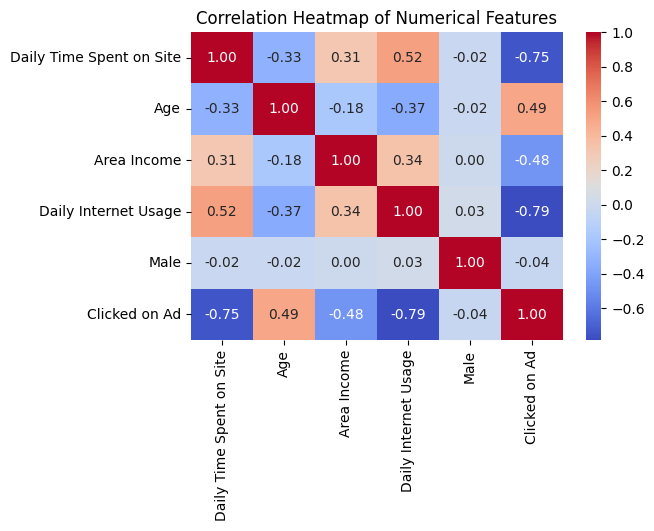

In [26]:
df_corr=df.select_dtypes(include=['float64','int64']).corr()
plt.figure(figsize=(6,4))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

3. Feature Selection and Data Spliting

In [27]:
x = df[["Daily Time Spent on Site", "Daily Internet Usage"]] #features
y = df["Clicked on Ad"] #target
print("Features:")
print(x.head())
print("\nTarget:")
print(y.head())

Features:
   Daily Time Spent on Site  Daily Internet Usage
0                     68.95                256.09
1                     80.23                193.77
2                     69.47                236.50
3                     74.15                245.89
4                     68.37                225.58

Target:
0    0
1    0
2    0
3    0
4    0
Name: Clicked on Ad, dtype: int64


In [28]:
#Split data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (800, 2)
Testing data: (200, 2)


In [29]:
#Init scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # Scale training data
x_test_scaled = scaler.transform(x_test) #Scale test data
x_test_sc=pd.DataFrame(x_test_scaled)

In [15]:
x_test_sc.describe()

,0,1
count,200.000000,200.000000
mean,-0.004551,-0.046930
std,1.006542,1.014262
min,-2.027715,-1.722907
25%,-0.917211,-1.032759
50%,0.173082,0.028423
75%,0.812731,0.857195
max,1.572383,1.778611


4. Model Training

In [30]:
# import model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
# train model
model.fit(x_train_scaled, y_train)

LogisticRegression()

In [31]:
#predict labels
y_pred = model. predict(x_test_scaled)
y_probability = model.predict_proba(x_test_scaled)[:, 1]
print("predicted calsses:")
print(y_pred[:10])
print("\nPredicted probabilities:")
print(y_probability[:10])

predicted calsses:
[1 0 0 0 1 1 1 1 0 0]

Predicted probabilities:
[0.99878923 0.0189869  0.00817417 0.07414317 0.98485865 0.99751288
 0.94456674 0.94819075 0.16328692 0.02313479]


5. Model Evalution

In [32]:
# Calculate accuracy
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy", accuracy)

Accuracy 0.96


Confusion Matrix

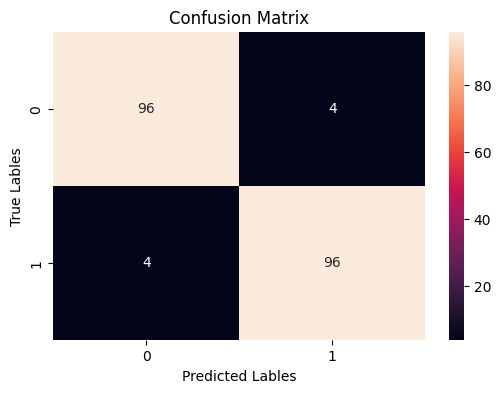

In [35]:
#Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Lables')
plt.ylabel('True Lables')
plt.show()

Classification Report

In [36]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       100
           1       0.96      0.96      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



In [37]:
from sklearn.metrics import precision_score
print('Precision', precision_score(y_test, y_pred))

Precision 0.96


ROC Curve and AUC

AUC: 0.9869


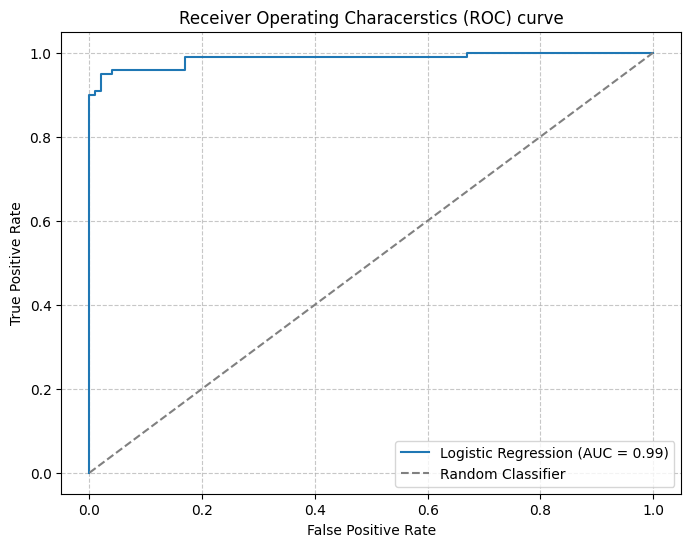

In [38]:
from sklearn.metrics import roc_auc_score, roc_curve
#Calculate FPR, TPR, Thersholds
fpr, tpr, threshold = roc_curve(y_test, y_probability)
#Calculate AUC
auc = roc_auc_score(y_test, y_probability)
print("AUC:", auc)
#plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")
#plot random classifier
plt.plot([0, 1], [0, 1], linestyle="--", color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characerstics (ROC) curve")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Sigmoid Function

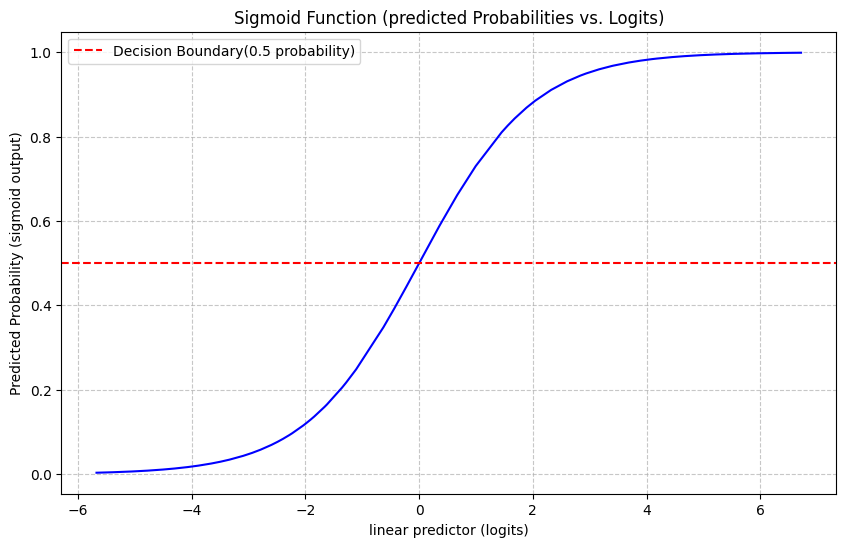

In [39]:
#claculate logits
logits = x_test_scaled @ model.coef_.T + model.intercept_
#sort for plot
sorted_indices = np.argsort(logits.flatten())
sorted_logits = logits.flatten()[sorted_indices]
sorted_probabilities = y_probability[sorted_indices]
#plot sigmoid
plt.figure(figsize=(10, 6))
plt.plot(sorted_logits, sorted_probabilities, color='blue')
plt.xlabel("linear predictor (logits)")
plt.ylabel("Predicted Probability (sigmoid output)")
plt.title("Sigmoid Function (predicted Probabilities vs. Logits)")
plt.grid(True, linestyle='--', alpha=0.7)
#Add decision boundary
plt.axhline(0.5, color='red', linestyle='--', label='Decision Boundary(0.5 probability)')
plt.legend()
plt.show()